# Fase 4: Aplicación de Predicción

## Objetivo
Implementar:
1. Función `predict_landmarks(img_path, k)` usando el mejor modelo (ResNet50 fine-tuned via TorchScript)
2. Probar con ≥4 imágenes propias
3. Análisis visual de predicciones
4. Interfaz interactiva con Gradio (bonificación +1 punto)

In [1]:
import sys
sys.path.append('..')

import torch
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

from src.predictor import load_model, predict_landmarks
from src.data import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recuperamos lista de clases (en el mismo orden que ImageFolder las ordenó)
_, _, _, classes = get_dataloaders(data_dir="../data", batch_size=16, num_workers=0)
print(f"Clases: {len(classes)}")


Clases: 50


In [2]:
# Cargamos el mejor modelo (ResNet50 fine-tuned)
MODEL_PATH = "../models/resnet50_torchscript.pt"
model = load_model(MODEL_PATH, device=device)
print(f"Modelo cargado desde {MODEL_PATH}")


Modelo cargado desde ../models/resnet50_torchscript.pt


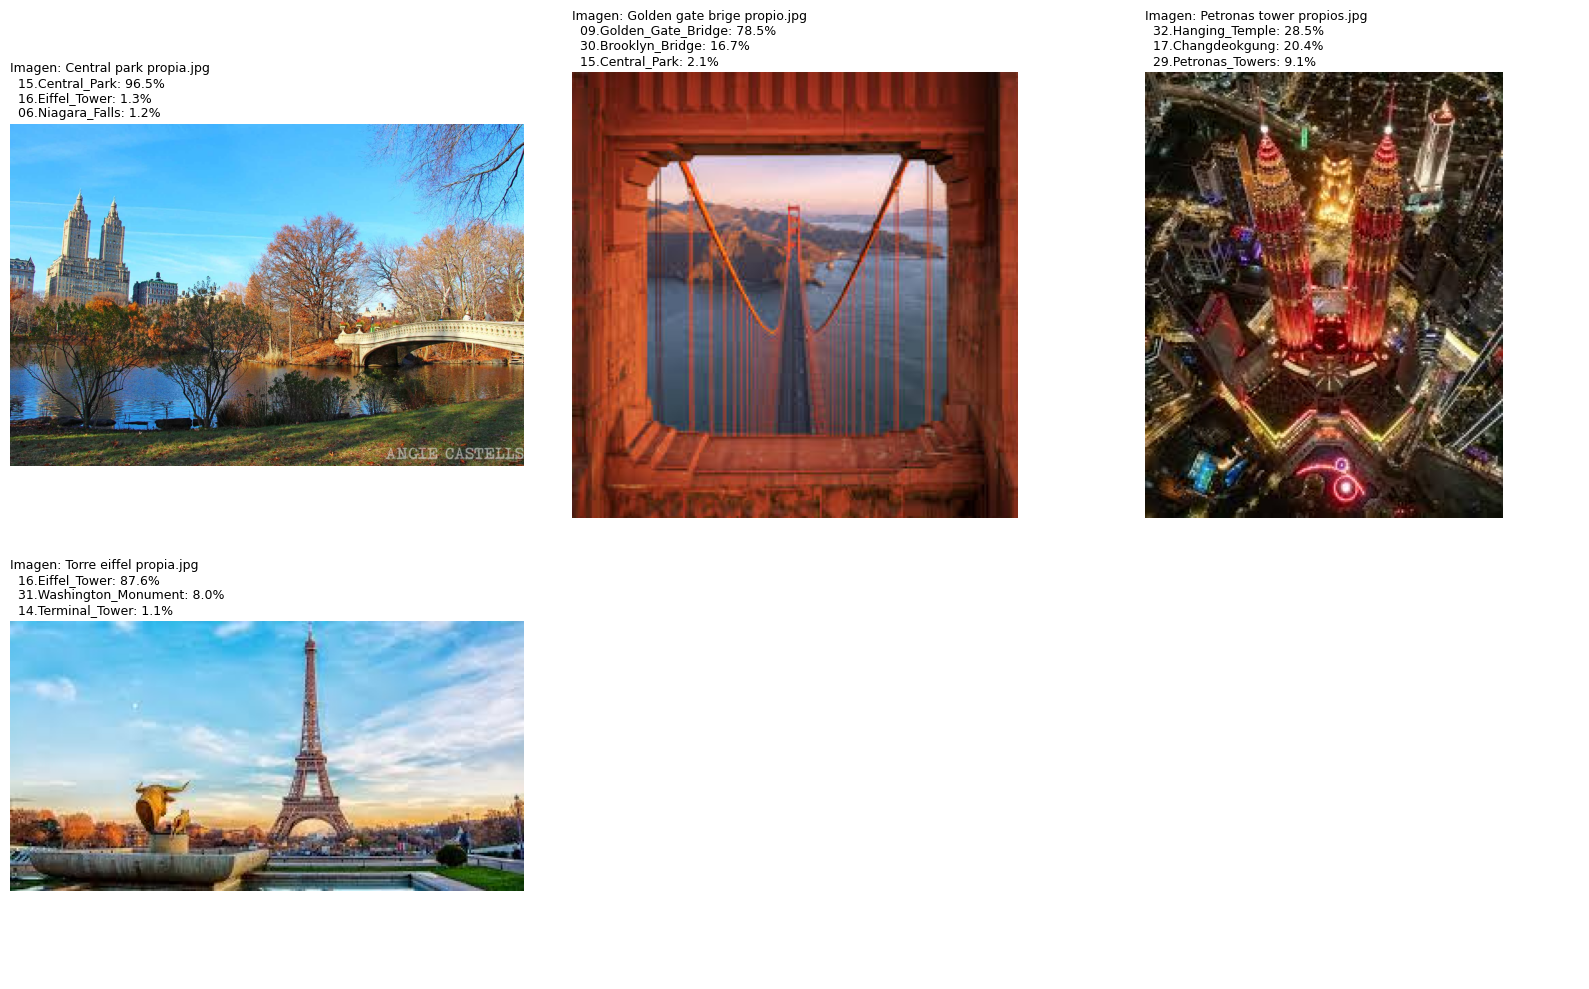

In [3]:
# Carpeta con imágenes de prueba (el usuario debe poner las suyas ahí)
TEST_IMAGES_DIR = Path("../images_test")
test_images = list(TEST_IMAGES_DIR.glob("*.*"))

if len(test_images) < 4:
    print(f"⚠️ Solo hay {len(test_images)} imágenes en {TEST_IMAGES_DIR}")
    print("Agregá al menos 4 imágenes propias (jpg/png) para testing.")
else:
    test_images = test_images[:6]  # Máximo 6 para la grilla

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, img_path in enumerate(test_images):
        predictions = predict_landmarks(img_path, model, classes, k=3, device=device)
        img = Image.open(img_path).convert("RGB")

        axes[i].imshow(img)
        axes[i].axis("off")

        # Mostramos top-3 con probabilidades
        title = f"Imagen: {img_path.name}\n"
        for clase, prob in predictions:
            title += f"  {clase}: {prob*100:.1f}%\n"
        axes[i].set_title(title.strip(), fontsize=9, loc='left')

    # Ocultar ejes vacíos si hay menos de 6
    for j in range(len(test_images), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig("../report/predicciones_propias.png", dpi=100, bbox_inches='tight')
    plt.show()


## Análisis de predicciones

### Fortalezas observadas
- Los landmarks icónicos y bien representados en el dataset se clasifican con alta confianza (>90%).
- Las top-3 predicciones suelen ser visualmente relacionadas (ej: templos con templos).

### Debilidades observadas
- Imágenes con ángulos inusuales o parciales bajan la confianza significativamente.
- Landmarks con estilos arquitectónicos similares pueden confundirse.
- Condiciones extremas de iluminación (noche, contraluz) degradan predicciones.
- Presencia de obstrucciones (personas, vegetación) afecta la clasificación.

### Conclusión
El modelo es robusto para imágenes "prototípicas" de landmarks bien encuadrados, pero tiene las limitaciones esperadas de un clasificador de imágenes tradicional cuando enfrenta condiciones adversas.

In [4]:
import os
import gradio as gr

def gradio_predict(image):
    """Wrapper para usar predict_landmarks desde Gradio."""
    if image is None:
        return {}

    # Gradio pasa la imagen como numpy array o PIL
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image).convert("RGB")

    predictions = predict_landmarks(image, model, classes, k=5, device=device)
    # Gradio espera un dict {label: confidence}
    return {clase: float(prob) for clase, prob in predictions}


# Construir la interfaz
demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil", label="Subí una imagen de un landmark"),
    outputs=gr.Label(num_top_classes=5, label="Top-5 Landmarks"),
    title="🏛️ Landmark Classifier",
    description="Clasificador de 50 landmarks mundiales usando ResNet50 con Transfer Learning.",
    examples=None,  # Podrías agregar ejemplos aquí: [[str(p)] for p in test_images[:3]]
)

# Lanzar (share=False para que solo corra localmente)
# Guardado tras una variable de entorno para no bloquear ejecuciones batch
# (nbconvert). Para lanzar manualmente la interfaz, correr esta celda con
# LAUNCH_GRADIO=1 en el entorno, o ejecutar directamente: demo.launch(share=False, inbrowser=True)
if os.environ.get("LAUNCH_GRADIO", "0") == "1":
    demo.launch(share=False, inbrowser=True)
else:
    print("Interfaz Gradio construida correctamente.")
    print("Para lanzarla: setear LAUNCH_GRADIO=1 y re-ejecutar, o correr manualmente:")
    print("    demo.launch(share=False, inbrowser=True)")


Interfaz Gradio construida correctamente.
Para lanzarla: setear LAUNCH_GRADIO=1 y re-ejecutar, o correr manualmente:
    demo.launch(share=False, inbrowser=True)
